# Open WOD datasets

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gsw

### Plot vars

In [3]:
apb_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/APB/*.nc')

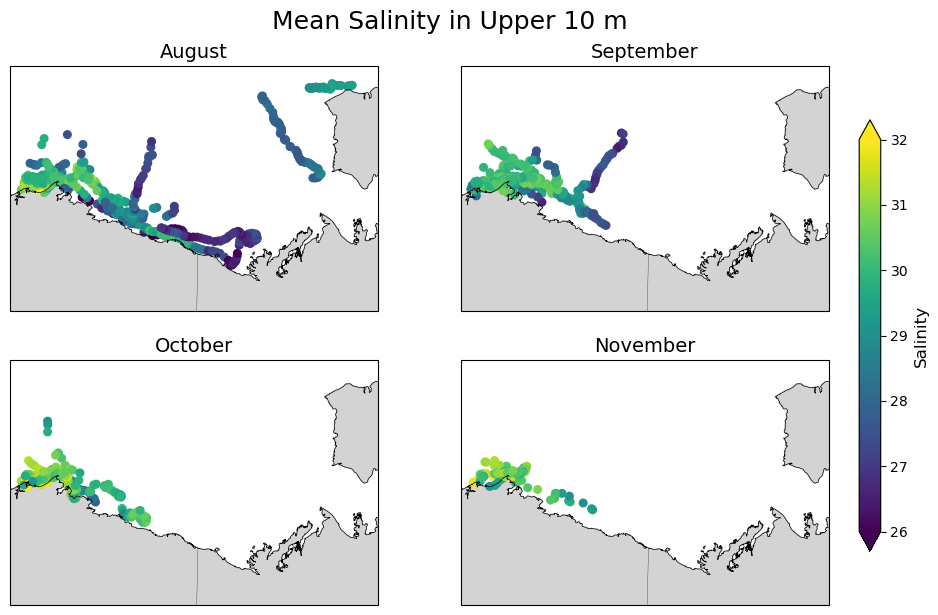

In [10]:
# months you want to plot
months = [8, 9, 10, 11]
month_names = {8: "August", 9: "September", 10: "October", 11: "November"}

# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, axes = plt.subplots(2, 2, figsize=(13, 7),
                         subplot_kw={'projection': proj})

axes = axes.flatten()

# keep reference to last scatter for colorbar
sc = None

for ax, month in zip(axes, months):

    # set map extent
    ax.set_extent([-157.5, -125, 67, 75.5], crs=ccrs.PlateCarree())

    # add isobaths
    # bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

    # add map features
    ax.add_feature(cfeature.LAND, color='lightgray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    # gridlines (no labels)
    # gl = ax.gridlines(draw_labels=False, dms=True,
    #                   x_inline=False, y_inline=False)

    # subset each dataset by month
    apb_m = apb_ds.where(apb_ds.time.dt.month == month, drop=True)

    # SCATTER PLOTS (capturing the last one for colorbar)
    sc = ax.scatter(
        apb_m.lon, apb_m.lat, s=30,
        c=apb_m.Salinity.sel(z=slice(0,10)).mean('z'),
        vmin=26, vmax=32, transform=ccrs.PlateCarree()
    )

    # panel title
    ax.set_title(f"{month_names[month]}", fontsize=14)
    
fig.suptitle("Mean Salinity in Upper 10 m          ", fontsize=18, y=0.96)

cbar = fig.colorbar(sc, ax=axes, location='right', shrink=0.8, pad=0.03, extend='both')
cbar.set_label("Salinity", fontsize=12)

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

### Plot profiles near Mackenzie River mouth

In [5]:
def compute_mld_profiles(apb_ds, rho_thresh=0.1):
    """
    Compute mixed layer depth using a 0.1 kg/m^3 density threshold.
    Uses z (m, positive downward) instead of pressure.
    
    Parameters
    ----------
    apb_ds : xarray.Dataset
        Must include:
        - Salinity(time, z)
        - Temperature(time, z)
        - z (m, positive downward)
        - Latitude(time)
        - Longitude(time)
    rho_thresh : float
        Density increase threshold (kg/m^3).
    
    Returns
    -------
    xarray.DataArray of MLD (time).
    """

    # Convert depth (m) → pressure (dbar)
    pressure = apb_ds.z  # 1 m ≈ 1 dbar

    # Broadcast latitude + longitude to match (time, z)
    lat2d = apb_ds.lat.broadcast_like(apb_ds.Salinity)
    lon2d = apb_ds.lon.broadcast_like(apb_ds.Salinity)

    # Compute Absolute Salinity and Conservative Temperature
    SA = gsw.SA_from_SP(apb_ds.Salinity, pressure, lon2d, lat2d)
    CT = gsw.CT_from_t(SA, apb_ds.Temperature, pressure)

    # Compute density (kg/m^3)
    rho = gsw.rho(SA, CT, pressure)

    mld_list = []

    # Loop profiles
    for t in apb_ds.time:
        rho_profile = rho.sel(time=t)
        depth_profile = apb_ds.z  # same for all times

        # reference density at **uppermost valid measurement**
        valid_idx = np.where(~np.isnan(rho_profile.values))[0]
        if len(valid_idx) == 0:
            mld_list.append(np.nan)
            continue

        rho0 = rho_profile.isel(z=valid_idx[0]).values

        # density anomaly relative to surface
        drho = rho_profile - rho0

        # first z where drho >= threshold
        idx = np.argmax(drho.values >= rho_thresh)

        if drho[idx] >= rho_thresh:
            mld = depth_profile.isel(z=idx).item()
        else:
            mld = np.nan  # no mixed layer depth found

        mld_list.append(mld)

    # Return as DataArray
    return xr.DataArray(
        mld_list,
        coords={'time': apb_ds.time},
        dims=['time'],
        name='MLD',
        attrs={'units': 'm', 'long_name': 'Mixed Layer Depth (0.1 kg/m^3 threshold)'}
    )

In [7]:
def compute_mld(ds, rho_thresh=0.03, lon=-137, lat=71):
    """
    Compute mixed layer depth (MLD) from a single vertical profile and 
    return both the MLD value and the computed density profile.

    Parameters
    ----------
    ds : xarray.Dataset
        Must contain 1D variables:
        - ds.Salinity (PSU)
        - ds.Temperature (°C, in-situ)
        - ds.z (depth, meters, positive downward)
    rho_thresh : float
        Density difference threshold (kg/m^3). Default = 0.03.
    lon, lat : float
        Geographic coordinates for SA_from_SP.

    Returns
    -------
    mld : float
        Mixed layer depth in meters. Returns NaN if MLD cannot be computed.
    rho : xarray.DataArray
        Density profile (kg/m^3), same shape and coords as ds.z.
    """

    # depth (m) approximates pressure (dbar)
    pressure = ds.z.values

    # Absolute Salinity & Conservative Temperature
    SA = gsw.SA_from_SP(ds.Salinity, pressure, lon, lat)
    CT = gsw.CT_from_t(SA, ds.Temperature, pressure)

    # Density (kg/m^3)
    rho = gsw.rho(SA, CT, pressure)

    # First valid density point = "surface"
    valid_idx = np.where(~np.isnan(rho))[0]
    if len(valid_idx) == 0:
        return np.nan, rho

    surface_idx = valid_idx[0]
    rho0 = rho[surface_idx]

    # Density anomaly
    drho = rho - rho0

    # Depth where density increases by threshold
    meets_threshold = drho.values >= rho_thresh

    if not np.any(meets_threshold):
        mld = np.nan
    else:
        idx = np.argmax(meets_threshold)
        mld = pressure[idx].item()

    return mld, rho
    # return meets_threshold

In [9]:
# open bathymetry
bathy_ds = xr.open_dataset('/Users/mzahn/data/GEBCO/GEBCO_2023.nc')

In [11]:
bathy_beaufort = bathy_ds.elevation.sel(lat=slice(68,80,5),lon=slice(-170,-120,5))

In [15]:
# select the month of August 2019
pinn_aug19 = apb_ds.sel(time='2019-08')

In [17]:
# calculate max depth of profile
last_valid_depths = []

for t in range(pinn_aug19.time.size):
    sal_profile = pinn_aug19.Salinity.isel(time=t)  # select profile
    valid_depths = pinn_aug19.z[~np.isnan(sal_profile).compute()]  # depths with valid Salinity
    if len(valid_depths) > 0:
        last_valid_depths.append(valid_depths[-1].item())  # deepest valid depth
    else:
        last_valid_depths.append(np.nan)  # no valid data

bottom_of_prof_da = xr.DataArray(last_valid_depths, coords={'time': pinn_aug19.time}, dims='time')

In [19]:
# now filter out profiles that only went to 5 m depth
pinn_aug19_deep = pinn_aug19.isel(time=bottom_of_prof_da>7)

# filter out profiles where T profile was flagged (bad)
pinn_aug19_Tfilter = pinn_aug19_deep.where((pinn_aug19_deep.Temperature_WODprofileflag==0).compute(),drop=True)

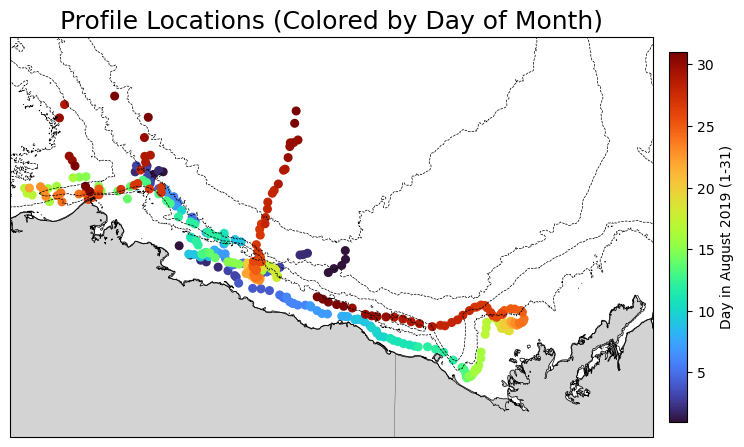

In [23]:
# extract day of month (1–31)
days = pinn_aug19.time.dt.day

# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(10, 6),
                       subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-157.5, -130, 68, 74], crs=ccrs.PlateCarree())

# map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# isobaths
bathy_beaufort.plot.contour(
    ax=ax,
    levels=[0, -50, -100, -1000, -3000],
    colors='k',
    linewidths=0.5,
    transform=ccrs.PlateCarree()
)

# SCATTER PLOTS — colored by day of month
sc = ax.scatter(
    pinn_aug19.lon,
    pinn_aug19.lat,
    s=30,
    c=days,
    cmap='turbo',
    vmin=1,
    vmax=31,
    transform=ccrs.PlateCarree()
)

# colorbar
cbar = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Day in August 2019 (1-31)")

plt.title("Profile Locations (Colored by Day of Month)", fontsize=18)

plt.show()

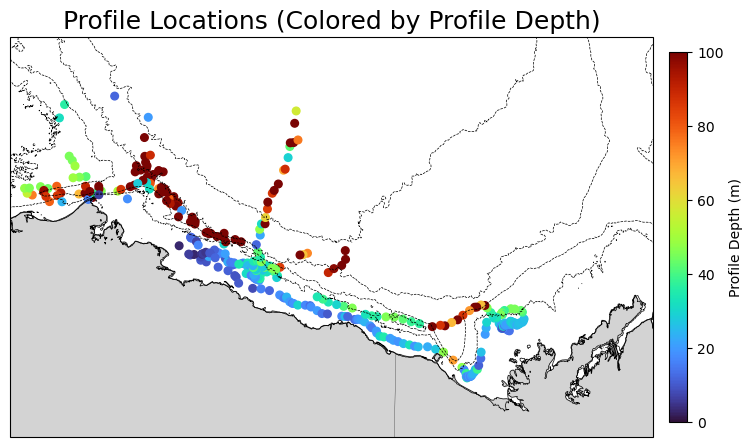

In [25]:
# extract day of month (1–31)
days = pinn_aug19.time.dt.day

# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(10, 6),
                       subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-157.5, -130, 68, 74], crs=ccrs.PlateCarree())

# map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# isobaths
bathy_beaufort.plot.contour(
    ax=ax,
    levels=[0, -50, -100, -1000, -3000],
    colors='k',
    linewidths=0.5,
    transform=ccrs.PlateCarree()
)

# SCATTER PLOTS — colored by day of month
sc = ax.scatter(
    pinn_aug19.lon,
    pinn_aug19.lat,
    s=30,
    c=bottom_of_prof_da,
    cmap='turbo',
    vmin=0,
    vmax=100,
    transform=ccrs.PlateCarree()
)

# colorbar
cbar = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Profile Depth (m)")

# plt.title("August 2019 Pinniped Profile Locations (Colored by Profile Depth)", fontsize=18)
plt.title("Profile Locations (Colored by Profile Depth)", fontsize=18)

plt.show()

In [63]:
# pinniped_mack = pinn_aug19_Tfilter.where(apb_ds.lon>-140,drop=True).where(apb_ds.lat<71,drop=True)
pinniped_mack = pinn_aug19_Tfilter.where(pinn_aug19_Tfilter.lon>-140,drop=True).where(pinn_aug19_Tfilter.lat<71,drop=True)

In [65]:
len(pinniped_mack.time)

75

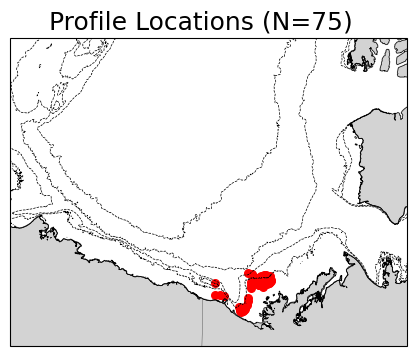

In [67]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(6, 4),
                         subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-156, -125, 67.5, 77], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# add isobaths
bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# SCATTER PLOTS (capturing the last one for colorbar)
sc = ax.scatter(
    pinniped_mack.lon, pinniped_mack.lat, s=30,
    c='r',transform=ccrs.PlateCarree()
)

fig.suptitle("Profile Locations (N=75)", fontsize=18, y=0.95)

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

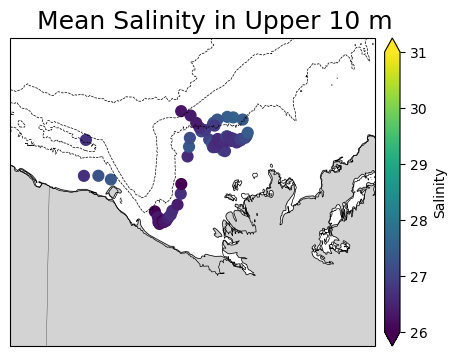

In [33]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(6, 4),
                         subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-142, -132, 68, 71], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# add isobaths
bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# SCATTER PLOTS (capturing the last one for colorbar)
sc = ax.scatter(
    pinniped_mack.lon, pinniped_mack.lat, s=60,
    c=pinniped_mack.Salinity.sel(z=slice(0,10)).mean('z'),vmin=26,vmax=31,transform=ccrs.PlateCarree()
)

fig.suptitle("Mean Salinity in Upper 10 m", fontsize=18, y=0.95)

# colorbar
cbar = fig.colorbar(sc, ax=ax, extend='both', pad=0.02)
cbar.set_label("Salinity")

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

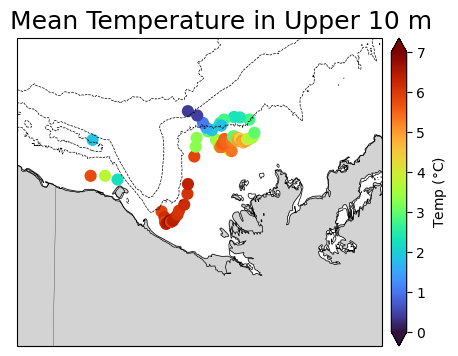

In [35]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(6, 4),
                         subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-142, -132, 68, 71], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# add isobaths
bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# SCATTER PLOTS (capturing the last one for colorbar)
sc = ax.scatter(
    pinniped_mack.lon, pinniped_mack.lat, s=60,cmap='turbo',
    c=pinniped_mack.Temperature.sel(z=slice(0,10)).mean('z'),vmin=0,vmax=7,transform=ccrs.PlateCarree()
)

fig.suptitle("Mean Temperature in Upper 10 m", fontsize=18, y=0.95)

# colorbar
cbar = fig.colorbar(sc, ax=ax, extend='both', pad=0.02)
cbar.set_label(r"Temp ($\degree$C)")

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

In [37]:
pinniped_mack_mld = compute_mld_profiles(pinniped_mack, rho_thresh=0.1)

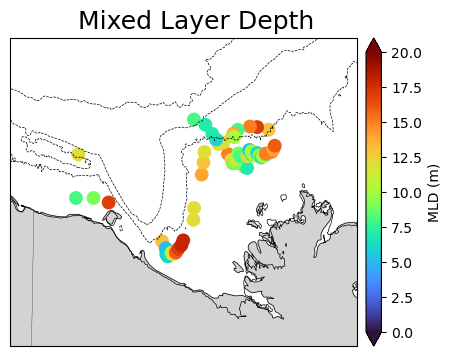

In [38]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(6, 4),
                         subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-141.5, -133.5, 68.5, 71], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# add isobaths
bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# SCATTER PLOTS (capturing the last one for colorbar)
sc = ax.scatter(
    pinniped_mack.lon, pinniped_mack.lat, s=80,cmap='turbo',
    c=pinniped_mack_mld,vmin=0,vmax=20,transform=ccrs.PlateCarree()
)

fig.suptitle("Mixed Layer Depth", fontsize=18, y=0.95)

# colorbar
cbar = fig.colorbar(sc, ax=ax, extend='both', pad=0.02)
cbar.set_label("MLD (m)")

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

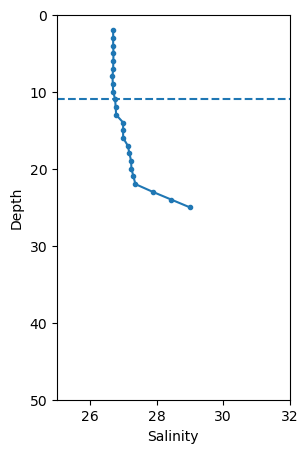

In [39]:
# 7 is good example
i=55
mld_tmp = pinniped_mack_mld.isel(time=i)

pinniped_mack.Salinity.isel(time=i).plot(add_legend=False,y='z',marker='.',figsize=[3,5])
plt.axhline(y=mld_tmp,linestyle='dashed')
plt.xlim(25,32)
plt.ylabel('Depth')
plt.title("")
plt.ylim(50,0);

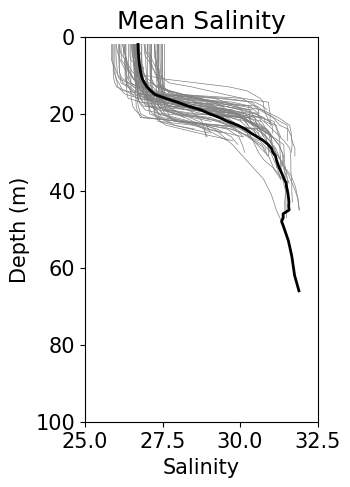

In [40]:
plt.rcParams['font.size'] = 15
pinniped_mack.Salinity.plot(hue='time',y='z',c='gray',linewidth=0.5,\
                            add_legend=False,label='All Profiles',figsize=[3,5])
pinniped_mack.Salinity.mean('time').plot(y='z',c='k',linewidth=2,label='Mean')
plt.ylim(100,0)
plt.xlim(25,32.5)
plt.title('Mean Salinity')
plt.ylabel('Depth (m)');

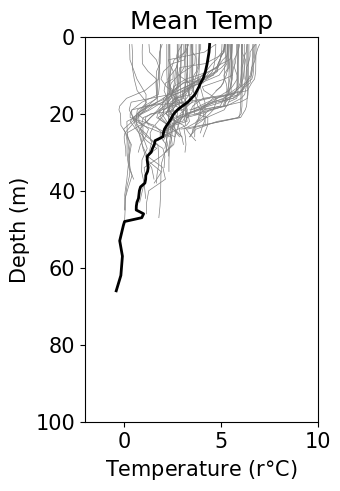

In [87]:
plt.rcParams['font.size'] = 15
pinniped_mack.Temperature.plot(hue='time',y='z',c='gray',linewidth=0.5,\
                            add_legend=False,label='All Profiles',figsize=[3,5])
pinniped_mack.Temperature.mean('time').plot(y='z',c='k',linewidth=2,label='Mean')
plt.ylim(100,0)
plt.xlim(-2,10)
plt.title('Mean Temp')
plt.xlabel('Temperature (r$\degree$C)')
plt.ylabel('Depth (m)');

In [51]:
pinniped_mack_avg = pinniped_mack.mean('time')

In [53]:
mack_avg_mld_0pt1, pinniped_mack_avg_rho = compute_mld(pinniped_mack_avg, rho_thresh=0.1)
mack_avg_mld_0pt3, pinniped_mack_avg_rho = compute_mld(pinniped_mack_avg, rho_thresh=0.3)

In [55]:
print(mack_avg_mld_0pt1)
print(mack_avg_mld_0pt3)

9
13


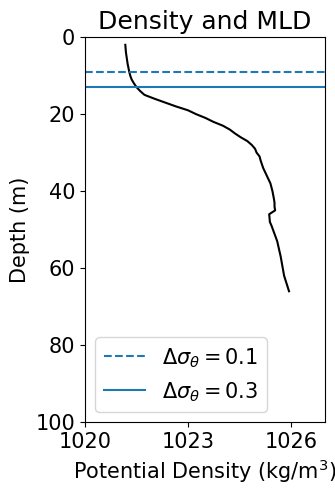

In [57]:
plt.rcParams['font.size'] = 15
pinniped_mack_avg_rho.plot(y='z',c='k',figsize=[3.1,5])
plt.axhline(y=mack_avg_mld_0pt1,linestyle='dashed',label = r'$\Delta \sigma_\theta = 0.1$')
plt.axhline(y=mack_avg_mld_0pt3,linestyle='solid',label = r'$\Delta \sigma_\theta = 0.3$')
plt.legend()
plt.ylim(100,0)
plt.xlim(1020,1027)
plt.xticks([1020,1023,1026])
plt.title("Density and MLD")
plt.xlabel('Potential Density (kg/m$^3$)');
plt.ylabel('Depth (m)');

In [59]:
# pinniped_west = pinn_aug19.where(pinn_aug19.lon>-157,drop=True).where(pinn_aug19.lon<-150,drop=True).where(pinn_aug19.lat<72,drop=True)
pinniped_west = pinn_aug19_Tfilter.where(pinn_aug19_Tfilter.lon>-157,drop=True).where(pinn_aug19_Tfilter.lon<-150,drop=True).where(pinn_aug19_Tfilter.lat<72,drop=True)

In [69]:
len(pinniped_west.time.values)

46

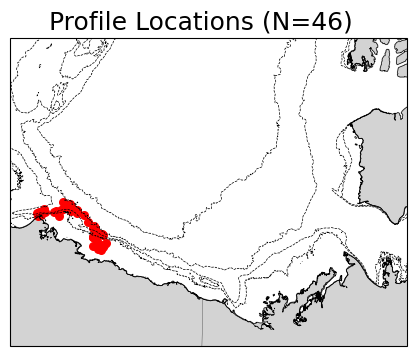

In [71]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(6, 4),
                         subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-156, -125, 67.5, 77], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# add isobaths
bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# SCATTER PLOTS (capturing the last one for colorbar)
sc = ax.scatter(
    pinniped_west.lon, pinniped_west.lat, s=30,
    c='r',transform=ccrs.PlateCarree()
)

fig.suptitle("Profile Locations (N=46)", fontsize=18, y=0.95)

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

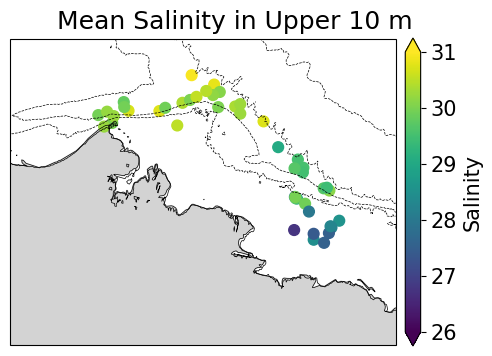

In [73]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(6, 4),
                         subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-158, -149, 70, 72], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# add isobaths
bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# SCATTER PLOTS (capturing the last one for colorbar)
sc = ax.scatter(
    pinniped_west.lon, pinniped_west.lat, s=60,
    c=pinniped_west.Salinity.sel(z=slice(0,10)).mean('z'),vmin=26,vmax=31,transform=ccrs.PlateCarree()
)

fig.suptitle("Mean Salinity in Upper 10 m", fontsize=18, y=0.95)

# colorbar
cbar = fig.colorbar(sc, ax=ax, extend='both', pad=0.02)
cbar.set_label("Salinity")

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

In [75]:
pinniped_west_mld = compute_mld_profiles(pinniped_west, rho_thresh=0.1)

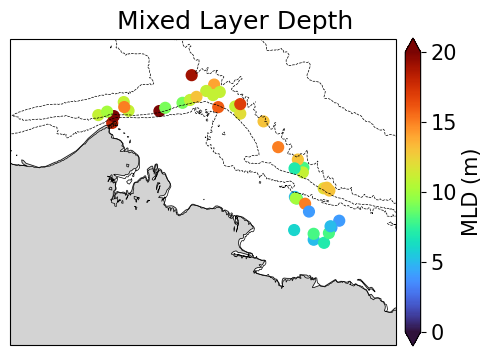

In [76]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(6, 4),
                         subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-158, -149, 70, 72], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# add isobaths
bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# SCATTER PLOTS (capturing the last one for colorbar)
sc = ax.scatter(
    pinniped_west.lon, pinniped_west.lat, s=60,cmap='turbo',
    c=pinniped_west_mld,vmin=0,vmax=20,transform=ccrs.PlateCarree()
)

fig.suptitle("Mixed Layer Depth", fontsize=18, y=0.95)

# colorbar
cbar = fig.colorbar(sc, ax=ax, extend='both', pad=0.02)
cbar.set_label("MLD (m)")

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

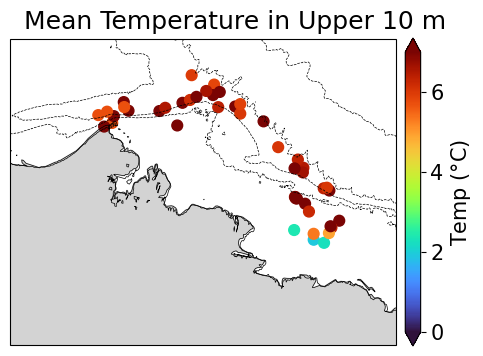

In [79]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(6, 4),
                         subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-158, -149, 70, 72], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# add isobaths
bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# SCATTER PLOTS (capturing the last one for colorbar)
sc = ax.scatter(
    pinniped_west.lon, pinniped_west.lat, s=60,cmap='turbo',
    c=pinniped_west.Temperature.sel(z=slice(0,10)).mean('z'),vmin=0,vmax=7,transform=ccrs.PlateCarree()
)

fig.suptitle("Mean Temperature in Upper 10 m", fontsize=18, y=0.95)

# colorbar
cbar = fig.colorbar(sc, ax=ax, extend='both', pad=0.02)
cbar.set_label(r"Temp ($\degree$C)")

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

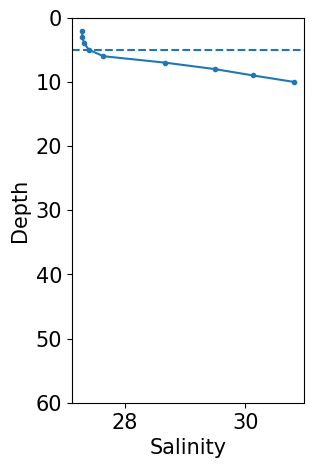

In [431]:
# 7 is good example
i=2
mld_tmp = pinniped_west_mld.isel(time=i)

pinniped_west.Salinity.isel(time=i).plot(add_legend=False,y='z',marker='.',figsize=[3,5])
plt.axhline(y=mld_tmp,linestyle='dashed')
# plt.xlim(29,32)
plt.ylabel('Depth')
plt.title("")
plt.ylim(60,0);

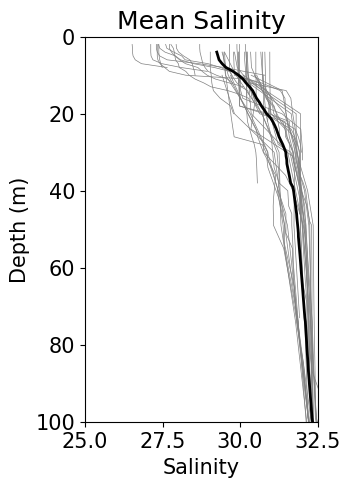

In [81]:
plt.rcParams['font.size'] = 15
pinniped_west.Salinity.plot(hue='time',y='z',c='gray',linewidth=0.5,\
                            add_legend=False,label='All Profiles',figsize=[3,5])
pinniped_west.Salinity.isel(z=slice(4,200)).mean('time').plot(y='z',c='k',linewidth=2,label='Mean')
plt.ylim(100,0)
plt.xlim(25,32.5)
plt.title('Mean Salinity')
plt.ylabel('Depth (m)');

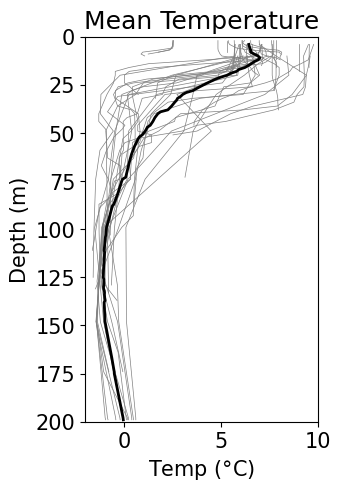

In [101]:
plt.rcParams['font.size'] = 15
pinniped_west.Temperature.plot(hue='time',y='z',c='gray',linewidth=0.5,\
                            add_legend=False,label='All Profiles',figsize=[3,5])
pinniped_west.Temperature.isel(z=slice(4,200)).mean('time').plot(y='z',c='k',linewidth=2,label='Mean')
plt.ylim(200,0)
plt.xlim(-2,10)
plt.title('Mean Temperature')
plt.xlabel('Temp ($\degree$C)')
plt.ylabel('Depth (m)');

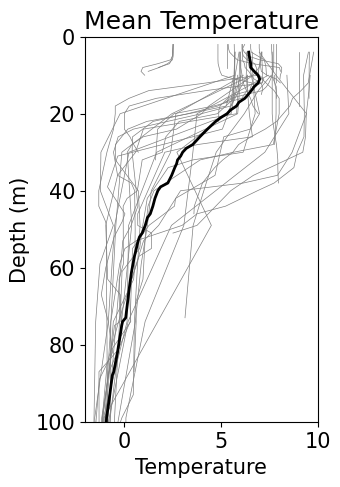

In [85]:
plt.rcParams['font.size'] = 15
pinniped_west.Temperature.plot(hue='time',y='z',c='gray',linewidth=0.5,\
                            add_legend=False,label='All Profiles',figsize=[3,5])
pinniped_west.Temperature.isel(z=slice(4,200)).mean('time').plot(y='z',c='k',linewidth=2,label='Mean')
plt.ylim(100,0)
plt.xlim(-2,10)
plt.title('Mean Temperature')
plt.ylabel('Depth (m)');

In [89]:
pinniped_west_avg = pinniped_west.isel(z=slice(4,200)).mean('time')

In [91]:
west_avg_mld_0pt1, pinniped_west_avg_rho = compute_mld(pinniped_west_avg, rho_thresh=0.1)
west_avg_mld_0pt3, pinniped_west_avg_rho = compute_mld(pinniped_west_avg, rho_thresh=0.3)

In [93]:
print(west_avg_mld_0pt1)
print(west_avg_mld_0pt3)

7
9


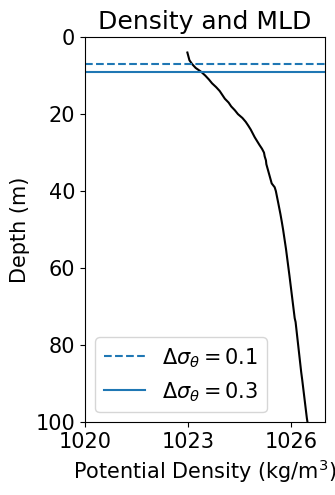

In [95]:
plt.rcParams['font.size'] = 15
pinniped_west_avg_rho.plot(y='z',c='k',figsize=[3.1,5])
plt.axhline(y=west_avg_mld_0pt1,linestyle='dashed',label = r'$\Delta \sigma_\theta = 0.1$')
plt.axhline(y=west_avg_mld_0pt3,linestyle='solid',label = r'$\Delta \sigma_\theta = 0.3$')
plt.legend()
plt.ylim(100,0)
plt.xlim(1020,1027)
plt.xticks([1020,1023,1026])
plt.title("Density and MLD")
plt.xlabel('Potential Density (kg/m$^3$)');
plt.ylabel('Depth (m)');

### Stratification

In [113]:
mack_strat = pinniped_mack_avg_rho.sel(z=20).values - pinniped_mack_avg_rho.sel(z=2).values
mack_strat

2.060697469644765

In [118]:
pinniped_west_avg_rho

<xarray.DataArray 'Salinity' (z: 196)> Size: 2kB
dask.array<rho, shape=(196,), dtype=float64, chunksize=(196,), chunktype=numpy.ndarray>
Coordinates:
  * z        (z) int64 2kB 4 5 6 7 8 9 10 11 ... 192 193 194 195 196 197 198 199

In [120]:
west_strat = pinniped_west_avg_rho.sel(z=20).values - pinniped_west_avg_rho.sel(z=4).values
west_strat

1.473483002390367